# Pendulum Dynamics: From Simulation to Machine Learning

## Simple Pendulum Simulation

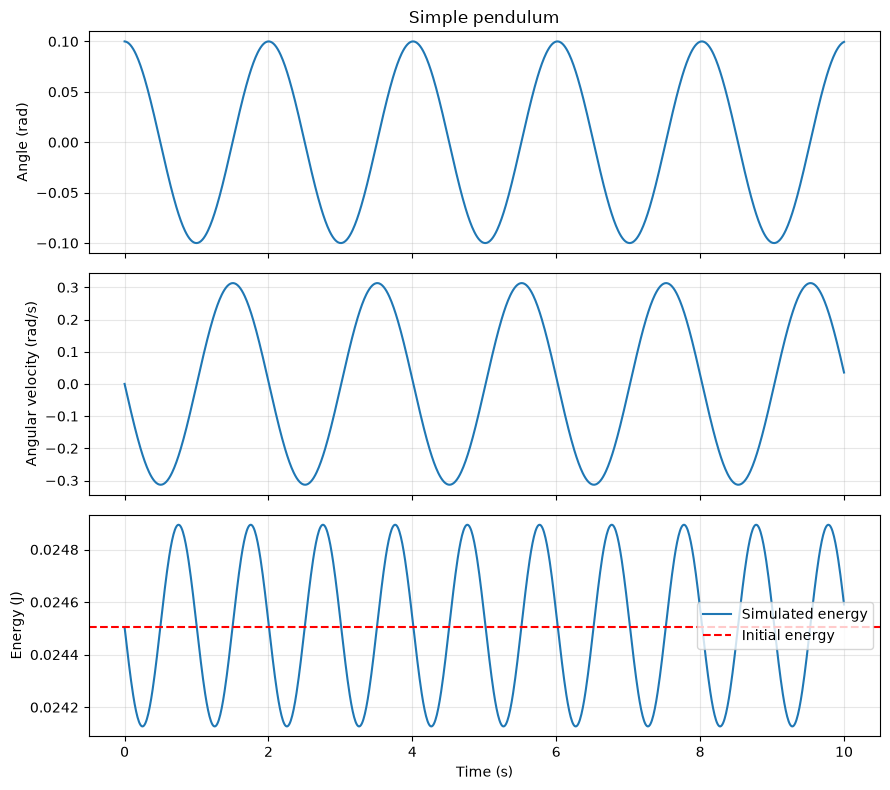

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

m = 0.5
l = 1.0
g = 9.81

theta = 0.1
omega = 0.0 # how quickly theta changes 

dt = 0.01       # time step in seconds
duration = 10.0
steps = round(duration / dt)
time = 0.0

# energies
ke = 0.5 * m * (l * omega)**2
gpe = m * g * l * (1 - np.cos(theta))  # mgh
initial_energy = ke + gpe

angles = {0.0: theta}
angular_velocities = {0.0: omega}
energy = {0.0: initial_energy} #use dict to see how energy is conserved

for step in range(steps):
    alpha = -(g / l) * np.sin(theta) #angular acceleration how quickly omega changes
    omega = omega + alpha * dt
    theta = theta + omega * dt
    time = time + dt
    ke = 0.5 * m * (l * omega)**2
    gpe = m * g * l * (1 - np.cos(theta))  
    total_energy = ke + gpe
    energy[time] = total_energy
    angles[time] = theta
    angular_velocities[time] = omega

#plotting graphs 
    #how does angle change with respect to time

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True) #creates 3 supblots

axes[0].plot(list(angles.keys()), list(angles.values())) #first plot
axes[0].set_ylabel("Angle (rad)")
axes[0].set_title("Simple pendulum")

axes[1].plot(
    list(angular_velocities.keys()),
    list(angular_velocities.values())
)
axes[1].set_ylabel("Angular velocity (rad/s)")

axes[2].plot(list(energy.keys()), list(energy.values()),
             label="Simulated energy")
axes[2].axhline(initial_energy, color="red", linestyle="--",
                label="Initial energy")
axes[2].set_ylabel("Energy (J)")
axes[2].set_xlabel("Time (s)")
axes[2].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Double Pendulum Simulation

#### Defining Variables

In [3]:
m1 = 0.5
m2 = 0.5
l1 = 1.0
l2 = 1.0

theta1 = 0.1
theta2 = 0.2
omega1 = 0.0
omega2 = 0.0

#treating fixed pivot as (0,0)
x1 = l1 * np.sin(theta1) #positions for 1st point mass
y1 = -l1 * np.cos(theta1)
x2 = x1 + (l2) * np.sin(theta2)#positions for 2nd point mass
y2 = y1 + -(l2) * np.cos(theta2)



# Derivation of Equations

### Velocity and kinetic energy of the first bob

Both angles are measured from vertically downwards.
Since $\theta_1$ changes with time, differentiating requires
the chain rule, with $\dot{\theta}_1 = \omega_1$.

$$
x_1 = l_1\sin\theta_1,
\qquad
y_1 = -l_1\cos\theta_1
$$

$$
\dot{x}_1 = l_1\cos\theta_1\,\omega_1,
\qquad
\dot{y}_1 = l_1\sin\theta_1\,\omega_1
$$

The speed squared is the sum of the squared velocity components:

$$
KE_1 = \frac12 m_1(\dot{x}_1^2+\dot{y}_1^2)
     = \frac12 m_1l_1^2\omega_1^2
       (\cos^2\theta_1+\sin^2\theta_1)
$$
Using $\cos^2\theta_1+\sin^2\theta_1=1$, this simplifies to:

$$
KE_1 = \frac12 m_1 l_1^2 \omega_1^2
$$

#### Gravitational potential energy

Taking the fixed pivot as zero height, with upwards positive:

$$
y_1=-l_1\cos\theta_1,
\qquad
y_2=-l_1\cos\theta_1-l_2\cos\theta_2
$$

Each bob contributes $mgy$, so:

$$
V=m_1gy_1+m_2gy_2
$$

Substituting and collecting terms:

$$
V=-m_1gl_1\cos\theta_1
  -m_2gl_1\cos\theta_1
  -m_2gl_2\cos\theta_2
$$

$$
\boxed{
V=-(m_1+m_2)gl_1\cos\theta_1-m_2gl_2\cos\theta_2
}
$$

Both masses appear in the first term because the first rod's
angle affects the height of both bobs. Negative potential energy
is valid: it follows from choosing the pivot as zero height.

### Kinetic energy of the second bob

The second bob's position is:

$$
x_2=l_1\sin\theta_1+l_2\sin\theta_2,
\qquad
y_2=-l_1\cos\theta_1-l_2\cos\theta_2
$$

Differentiating with respect to time, using
$\dot{\theta}_1=\omega_1$ and $\dot{\theta}_2=\omega_2$:

$$
\dot{x}_2=l_1\omega_1\cos\theta_1+l_2\omega_2\cos\theta_2
$$

$$
\dot{y}_2=l_1\omega_1\sin\theta_1+l_2\omega_2\sin\theta_2
$$

The speed squared is:

$$
v_2^2=\dot{x}_2^2+\dot{y}_2^2
$$

Expanding and grouping terms:

$$
\begin{aligned}
v_2^2={}&l_1^2\omega_1^2(\cos^2\theta_1+\sin^2\theta_1)\\
&+l_2^2\omega_2^2(\cos^2\theta_2+\sin^2\theta_2)\\
&+2l_1l_2\omega_1\omega_2
(\cos\theta_1\cos\theta_2+\sin\theta_1\sin\theta_2)
\end{aligned}
$$

Using $\cos^2\theta+\sin^2\theta=1$ and
$\cos(a-b)=\cos a\cos b+\sin a\sin b$:

$$
v_2^2=l_1^2\omega_1^2+l_2^2\omega_2^2
+2l_1l_2\omega_1\omega_2\cos(\theta_1-\theta_2)
$$

Therefore:

$$
\boxed{
KE_2=\frac12 m_2
\left[
l_1^2\omega_1^2+l_2^2\omega_2^2
+2l_1l_2\omega_1\omega_2\cos(\theta_1-\theta_2)
\right]
}
$$

The cross term accounts for how the two rods' motions combine
to determine the second bob's speed.

### Using the Lagrangian to derive the simple pendulum equation

We first apply the method to a simple pendulum to check that it
reproduces the acceleration equation used in our simulation.

Assume a point mass $m$, a massless rigid rod of length $l$,
a fixed pivot, and no friction. The angle $\theta$ is measured
from vertically downwards.

Angular velocity and acceleration are:

$$
\dot{\theta}=\frac{d\theta}{dt},
\qquad
\ddot{\theta}=\frac{d^2\theta}{dt^2}
$$

Taking the pivot as zero height, the energies are:

$$
T=\frac12 ml^2\dot{\theta}^2,
\qquad
V=-mgl\cos\theta
$$

The Lagrangian is kinetic energy minus potential energy.
It is not the total energy, which is $T+V$.

$$
\mathcal L=T-V
=\frac12 ml^2\dot{\theta}^2+mgl\cos\theta
$$

The Euler–Lagrange equation is:

$$
\frac{d}{dt}
\left(\frac{\partial\mathcal L}{\partial\dot{\theta}}\right)
-\frac{\partial\mathcal L}{\partial\theta}=0
$$

For the partial derivatives, we treat $\theta$ and
$\dot{\theta}$ as independent variables.

**1. Differentiate with respect to angular velocity**

Holding $\theta$ fixed, the cosine term contributes zero:

$$
\frac{\partial\mathcal L}{\partial\dot{\theta}}
=ml^2\dot{\theta}
$$

Then take the time derivative, with $m$ and $l$ constant:

$$
\frac{d}{dt}
\left(\frac{\partial\mathcal L}{\partial\dot{\theta}}\right)
=ml^2\ddot{\theta}
$$

**2. Differentiate with respect to angle**

Holding $\dot{\theta}$ fixed, the kinetic-energy term contributes zero:

$$
\frac{\partial\mathcal L}{\partial\theta}
=-mgl\sin\theta
$$

**3. Substitute into the Euler–Lagrange equation**

$$
ml^2\ddot{\theta}-(-mgl\sin\theta)=0
$$

$$
ml^2\ddot{\theta}+mgl\sin\theta=0
$$

Rearranging:

$$
\boxed{\ddot{\theta}=-\frac{g}{l}\sin\theta}
$$

This matches the angular acceleration used in our simulation:

`alpha = -(g / l) * np.sin(theta)`

No small-angle approximation was needed.

### 1. Double-pendulum Lagrangian

Assume two point masses connected by massless rigid rods, a fixed
pivot, and no friction. Both angles are measured from vertically
downwards, with:

$$
\omega_1=\dot{\theta}_1,\qquad
\omega_2=\dot{\theta}_2,\qquad
\Delta=\theta_1-\theta_2
$$

The total kinetic energy is:

$$
T=\frac12(m_1+m_2)l_1^2\omega_1^2
+\frac12m_2l_2^2\omega_2^2
+m_2l_1l_2\omega_1\omega_2\cos\Delta
$$

Taking the fixed pivot as zero height, the potential energy is:

$$
V=-(m_1+m_2)gl_1\cos\theta_1-m_2gl_2\cos\theta_2
$$

Therefore:

$$
\begin{aligned}
\mathcal L=T-V
={}&\frac12(m_1+m_2)l_1^2\omega_1^2
+\frac12m_2l_2^2\omega_2^2\\
&+m_2l_1l_2\omega_1\omega_2\cos\Delta\\
&+(m_1+m_2)gl_1\cos\theta_1+m_2gl_2\cos\theta_2
\end{aligned}
$$

We apply the Euler–Lagrange equation separately to each angle:

$$
\frac{d}{dt}
\left(\frac{\partial\mathcal L}{\partial\omega_i}\right)
-\frac{\partial\mathcal L}{\partial\theta_i}=0,
\qquad i=1,2
$$

For partial derivatives, angles and angular velocities are treated
as independent variables. For time derivatives, they evolve together.

### 2. Deriving the coupled equations of motion

Define angular accelerations:

$$
\alpha_1=\dot{\omega}_1,\qquad
\alpha_2=\dot{\omega}_2
$$

Since $\Delta=\theta_1-\theta_2$:

$$
\dot{\Delta}=\omega_1-\omega_2,
\qquad
\frac{d}{dt}\cos\Delta
=-\sin\Delta(\omega_1-\omega_2)
$$

#### Equation for the first angle

Differentiate the Lagrangian with respect to $\omega_1$:

$$
\frac{\partial\mathcal L}{\partial\omega_1}
=(m_1+m_2)l_1^2\omega_1
+m_2l_1l_2\omega_2\cos\Delta
$$

Taking its time derivative requires the product and chain rules:

$$
\begin{aligned}
\frac{d}{dt}
\left(\frac{\partial\mathcal L}{\partial\omega_1}\right)
={}&(m_1+m_2)l_1^2\alpha_1\\
&+m_2l_1l_2
\left[
\alpha_2\cos\Delta
-\omega_2\sin\Delta(\omega_1-\omega_2)
\right]
\end{aligned}
$$

Differentiate the Lagrangian with respect to $\theta_1$:

$$
\frac{\partial\mathcal L}{\partial\theta_1}
=-m_2l_1l_2\omega_1\omega_2\sin\Delta
-(m_1+m_2)gl_1\sin\theta_1
$$

Substituting into Euler–Lagrange, the mixed
$\omega_1\omega_2\sin\Delta$ terms cancel, leaving:

$$
\boxed{
(m_1+m_2)l_1^2\alpha_1
+m_2l_1l_2\cos\Delta\,\alpha_2
+m_2l_1l_2\omega_2^2\sin\Delta
+(m_1+m_2)gl_1\sin\theta_1=0
}
$$

#### Equation for the second angle

Differentiate with respect to $\omega_2$:

$$
\frac{\partial\mathcal L}{\partial\omega_2}
=m_2l_2^2\omega_2+m_2l_1l_2\omega_1\cos\Delta
$$

Taking the time derivative:

$$
\begin{aligned}
\frac{d}{dt}
\left(\frac{\partial\mathcal L}{\partial\omega_2}\right)
={}&m_2l_2^2\alpha_2\\
&+m_2l_1l_2
\left[
\alpha_1\cos\Delta
-\omega_1\sin\Delta(\omega_1-\omega_2)
\right]
\end{aligned}
$$

Because $\partial\Delta/\partial\theta_2=-1$, differentiating
$\cos\Delta$ with respect to $\theta_2$ gives $+\sin\Delta$:

$$
\frac{\partial\mathcal L}{\partial\theta_2}
=+m_2l_1l_2\omega_1\omega_2\sin\Delta
-m_2gl_2\sin\theta_2
$$

Substituting and cancelling the mixed terms:

$$
\boxed{
m_2l_2^2\alpha_2
+m_2l_1l_2\cos\Delta\,\alpha_1
-m_2l_1l_2\omega_1^2\sin\Delta
+m_2gl_2\sin\theta_2=0
}
$$

These equations are coupled: each contains both angular accelerations.
We must solve them together.

### 3. Solving for the accelerations and preparing for SciPy

Write the coupled equations as:

$$
A\alpha_1+B\alpha_2=r_1
$$

$$
B\alpha_1+C\alpha_2=r_2
$$

where:

$$
A=(m_1+m_2)l_1^2,
\qquad
B=m_2l_1l_2\cos\Delta,
\qquad
C=m_2l_2^2
$$

$$
r_1=-m_2l_1l_2\omega_2^2\sin\Delta
-(m_1+m_2)gl_1\sin\theta_1
$$

$$
r_2=+m_2l_1l_2\omega_1^2\sin\Delta
-m_2gl_2\sin\theta_2
$$

Eliminating one acceleration at a time gives:

$$
\boxed{\alpha_1=\frac{Cr_1-Br_2}{AC-B^2}}
$$

$$
\boxed{\alpha_2=\frac{Ar_2-Br_1}{AC-B^2}}
$$

The denominator simplifies to:

$$
AC-B^2=m_2l_1^2l_2^2
\left(m_1+m_2\sin^2\Delta\right)
$$

This is positive for positive masses and rod lengths.

#### State vector for numerical integration

Choose the state ordering:

$$
\mathbf{s}=
\begin{bmatrix}
\theta_1\\
\omega_1\\
\theta_2\\
\omega_2
\end{bmatrix}
$$

Its time derivative is:

$$
\frac{d\mathbf{s}}{dt}=
\begin{bmatrix}
\omega_1\\
\alpha_1\\
\omega_2\\
\alpha_2
\end{bmatrix}
$$

Our function for SciPy will receive the current time and state,
calculate the two accelerations, and return these four derivatives.
SciPy will handle advancing the state through time.

#### Energy check

The total mechanical energy is:

$$
E=T+V
$$

With no friction, the exact equations conserve this energy.
The numerical solution should keep it approximately constant.

In [4]:
# Goal is to use the equations to get the angular velocity of each pendulum at its current position and velocity
#defining variables to make the equations readable
delta = theta1 - theta2
A = (m1+m2) * (l1)**2
B = m2 * l1 * l2 * np.cos(delta)
C = m2 * (l2)**2

# take current state and return angular velocities and accelerations
s = np.array([theta1,omega1,theta2,omega2])
def update(t, s):
    theta1, omega1, theta2, omega2 = s

    delta = theta1 - theta2

    A = (m1 + m2) * l1**2
    B = m2 * l1 * l2 * np.cos(delta)
    C = m2 * l2**2

    r1 = -m2 * l1 * l2 * omega2**2 * np.sin(delta) \
         - (m1 + m2) * g * l1 * np.sin(theta1)

    r2 = m2 * l1 * l2 * omega1**2 * np.sin(delta) \
         - m2 * g * l2 * np.sin(theta2)

    # Solve for angular accelerations
    alpha1 = (C * r1 - B * r2) / (A * C - B**2)
    alpha2 = (A * r2 - B * r1) / (A * C - B**2)

    return [omega1, alpha1, omega2, alpha2]
#Scipy to calculate motion
solution = solve_ivp(update, (0,100), s,rtol=1e-9, atol=1e-11) #relative tolerance and absolute tolerance
solution.t     # times
solution.y[0]  # first pendulum's angle at each time

     

array([0.1       , 0.09999994, 0.09999914, ..., 0.08086105, 0.07966384,
       0.07880015], shape=(8442,))

### Double Pendulum Motion Plots

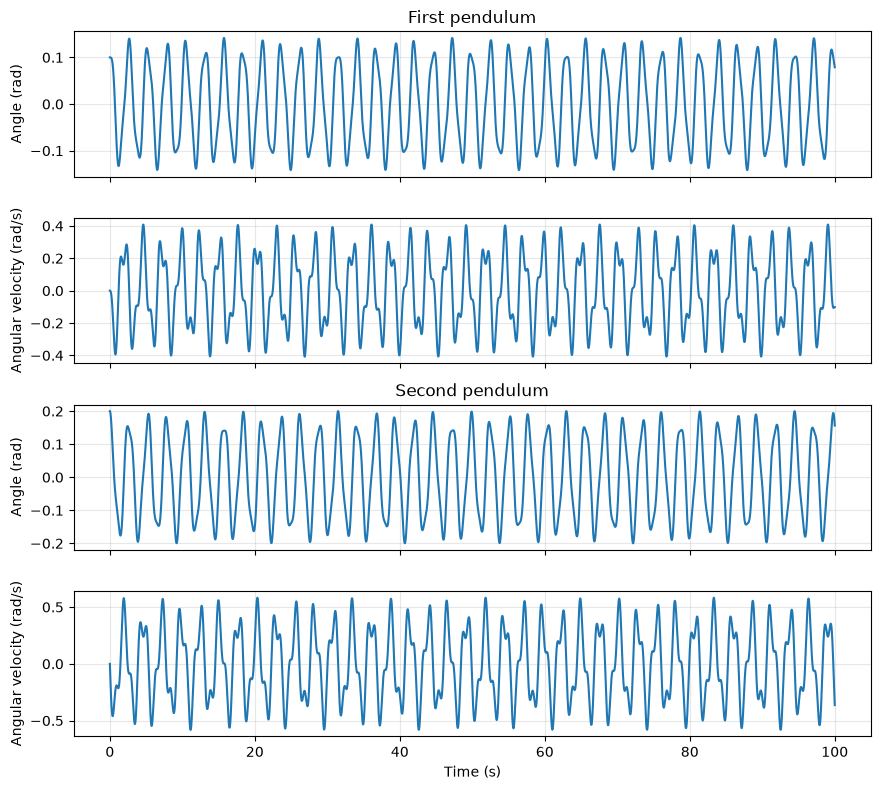

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True) #creates 4 supblots

axes[0].plot(list(solution.t), list(solution.y[0])) #first plot
axes[0].set_ylabel("Angle (rad)")
axes[0].set_title("First pendulum")

axes[1].plot(
    list(solution.t),
    list(solution.y[1]))
axes[1].set_ylabel("Angular velocity (rad/s)")
    
axes[2].plot(list(solution.t), list(solution.y[2])) #2nd plot
axes[2].set_ylabel("Angle (rad)")
axes[2].set_title("Second pendulum")

axes[3].plot(
    list(solution.t),
    list(solution.y[3]))
axes[3].set_ylabel("Angular velocity (rad/s)")
axes[3].set_xlabel("Time (s)")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Energy conservation 

In [8]:
theta1, omega1, theta2, omega2 = solution.y

#working out the KE of the system which is the KE of both pendulums at any pooint in time
kinetic_energy_1 = 0.5 * m1 * l1**2 * omega1**2

kinetic_energy_2 = (
    0.5 * m2
    * (
        l1**2 * omega1**2
        + l2**2 * omega2**2
        + 2 * l1 * l2 * omega1 * omega2
        * np.cos(theta1 - theta2)
    )
)
kinetic_energy = kinetic_energy_1 + kinetic_energy_2

# Gravitational potential energy
potential_energy_1 = -m1 * g * l1 * np.cos(theta1)

potential_energy_2 = m2 * g * (
    -l1 * np.cos(theta1)
    -l2 * np.cos(theta2)
)

potential_energy_total = potential_energy_1 + potential_energy_2


total_energy = potential_energy_total + kinetic_energy

energy_error = total_energy - total_energy[0]
relative_energy_error = (
    np.abs(energy_error)
    / np.abs(total_energy[0])
)
relative_energy_error_percent = relative_energy_error * 100
maximum_error = np.max(relative_energy_error_percent)
print(maximum_error)

2.070630756398228e-08


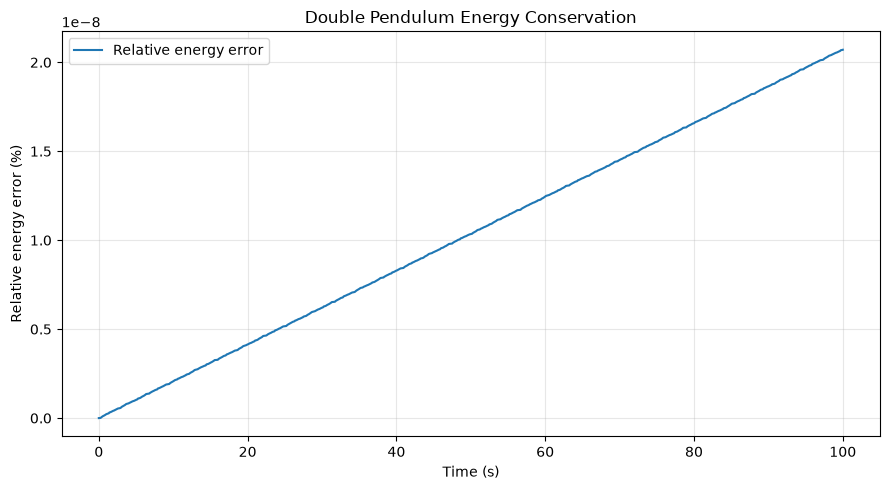

In [10]:
plt.figure(figsize=(9, 5))

plt.plot(
    solution.t,
    relative_energy_error_percent,
    label="Relative energy error"
)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.xlabel("Time (s)")
plt.ylabel("Relative energy error (%)")
plt.title("Double Pendulum Energy Conservation")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()